# Perfect World vs Peer Group
## A Financial Comparison Between Perfect World and  Peer Group

## Analytical Problem
Compared with similar game and entertainment firms, is Perfect World financially stable enough to support long-term game operations?

## Target User
This notebook is designed for game players, gaming consumers, and other users who want to understand whether a game company appears financially stable compared with its peers.

### Analytical Purpose
The purpose of this notebook is to transform financial statement data into an interpretable signal about whether Perfect World appears stronger or weaker than comparable firms in areas related to growth, financial pressure, and operating support.

### Data Source
Data source: WRDS / CSMAR

In [2]:
import wrds
import pandas as pd

In [3]:
# Replace the string below with your own WRDS account name (e.g. 'jsmith').
username = "YOUR_WRDS_USERNAME"
db = wrds.Connection(wrds_username=username)

Enter your WRDS username [YOUR_WRDS_USERNAME]: gloria666
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Extract and Prepare Perfect World Annual Data

This section extracts Perfect World’s financial statement data from WRDS/CSMAR and prepares it for analysis. The raw data are filtered to keep annual year-end observations only, renamed into readable variable names, and cleaned so that one observation remains for each year.

Five analytical indicators are then constructed:

- revenue growth
- debt ratio
- operating cash flow to assets
- net profit margin
- return on assets (ROA)

These indicators are used because they reflect business growth, financial pressure, profitability, and operating cash support, all of which are relevant to long-term game operations.

In [4]:
# Set the target company and the analysis period
stkcd = '002624'
start_date = '2019-12-31'
end_date = '2024-12-31'

# Select the key financial variables needed for this project
# b001100000 = revenue
# b002000000 = net income
# a001000000 = total assets
# a002000000 = total liabilities
# c001000000 = operating cash flow
selected_columns = """
stkcd,
shortname,
accper,
typrep,
b001100000,
b002000000,
a001000000,
a002000000,
c001000000
"""

# Build the SQL query to extract Perfect World's financial data
sql_query = f"""
SELECT {selected_columns}
FROM csmar.wrds_csmar_financial_master
WHERE stkcd = '{stkcd}'
  AND accper BETWEEN '{start_date}' AND '{end_date}'
ORDER BY accper
"""

# Run the query and load the result into a pandas DataFrame
df = db.raw_sql(sql_query, date_cols=['accper'])

# Rename the raw WRDS/CSMAR field names into readable variable names
df = df.rename(columns={
    'b001100000': 'revenue',
    'b002000000': 'net_income',
    'a001000000': 'total_assets',
    'a002000000': 'total_liabilities',
    'c001000000': 'operating_cash_flow'
})

# Keep only one report type for consistency
df = df[df['typrep'] == 'A'].copy()

# Keep only year-end observations
df = df[pd.to_datetime(df['accper']).dt.strftime('%m-%d') == '12-31'].copy()

# Create a year variable
df['year'] = pd.to_datetime(df['accper']).dt.year

# Sort the data and remove duplicate yearly observations
df = df.sort_values('accper').drop_duplicates(subset=['stkcd', 'year'])

# Construct the key financial indicators
df['revenue_growth'] = df['revenue'].pct_change()
df['debt_ratio'] = df['total_liabilities'] / df['total_assets']
df['ocf_to_assets'] = df['operating_cash_flow'] / df['total_assets']
df['net_profit_margin'] = df['net_income'] / df['revenue']
df['roa'] = df['net_income'] / df['total_assets']

# Keep only the variables needed for the final analysis
df = df[['stkcd', 'shortname', 'year', 'accper',
         'revenue', 'net_income', 'total_assets',
         'total_liabilities', 'operating_cash_flow',
         'revenue_growth', 'debt_ratio', 'ocf_to_assets',
         'net_profit_margin', 'roa']]

# Display the final prepared annual dataset for Perfect World
df

,stkcd,shortname,year,accper,revenue,net_income,total_assets,total_liabilities,operating_cash_flow,revenue_growth,debt_ratio,ocf_to_assets,net_profit_margin,roa
0,002624,WMSJ,2019,2019-12-31,8039021278.77,1447155065.47,16629394610.73,6500647724.46,2023440592.96,<NA>,0.390913,0.121679,0.180016,0.087024
10,002624,WMSJ,2020,2020-12-31,10224767171.309999,1504287486.34,15506930273.09,4324538166.79,3692549364.59,0.271892,0.278878,0.238123,0.147122,0.097007
19,002624,WMSJ,2021,2021-12-31,8517998133.61,177362555.72,17039505936.950001,6535086076.11,1097681874.57,-0.166925,0.383526,0.06442,0.020822,0.010409
27,002624,WMSJ,2022,2022-12-31,7670402228.08,1399589204.69,15635994534.059999,6159796956.09,1155208642.79,-0.099506,0.39395,0.073881,0.182466,0.089511
35,002624,WMSJ,2023,2023-12-31,7790717277.28,582595567.48,14488533708.41,5063762756.18,761820285.9,0.015686,0.349501,0.052581,0.074781,0.040211
43,002624,WMSJ,2024,2024-12-31,5570490164.67,-1400096630.81,11365625431.969999,4496058836.16,576532621.16,-0.284984,0.395584,0.050726,-0.251342,-0.123187


## 3. Identify Perfect World's WRDS Industry Category

This section uses the WRDS/CSMAR company table to identify the current industry classification of Perfect World. This serves as the starting point for building a more relevant peer group.

A broad industry category is useful for locating comparable firms, but it is not always precise enough for a game-focused analysis. Therefore, the broader category is only used as the first step in peer selection.

In [5]:
# Load the WRDS/CSMAR company table
trd_co_full = db.get_table('csmar', 'trd_co')

# Locate Perfect World in the company table
pw_row = trd_co_full[trd_co_full['stkcd'].astype(str) == '002624'].iloc[0]

# Display the most relevant company and industry information
pw_row[['stkcd', 'conme', 'nnindcd', 'nnindnme']]

stkcd                               002624
conme              Perfect World Co., Ltd.
nnindcd                                I64
nnindnme    Internet and Relevant Services
Name: 2467, dtype: object

## 4. Build a Refined WRDS/CSMAR Peer Group

This section constructs a relevant comparison group for Perfect World.

A narrower WRDS/CSMAR industry category is first used to identify firms related to Perfect World. However, even this narrower category still contains firms that are not directly related to games. Therefore, the peer group is refined by keeping firms whose names are more closely associated with games, interactive entertainment, or digital culture.

This refinement improves relevance for the research question, but it also has limitations. It may exclude some comparable firms and may still include firms with mixed business models. Therefore, the final peer group should be interpreted as a refined peer sample rather than the entire game industry.

In [6]:
# Use the narrower industry classification as the starting point for peer selection
industry_firms_nn = trd_co_full[trd_co_full['nnindcd'] == pw_row['nnindcd']].copy()
industry_firms_nn['stkcd'] = industry_firms_nn['stkcd'].astype(str)

# Define keywords related to games, interactive entertainment, and digital culture
keywords = ['Game', 'Interactive', 'Entertainment', 'Digital Culture', '游戏', '互娱', '网络', '文化']

# Keep firms whose short names or full company names match the selected keywords
mask = industry_firms_nn['conme'].astype(str).str.contains('|'.join(keywords), case=False, na=False) | \
       industry_firms_nn['stknme'].astype(str).str.contains('|'.join(keywords), case=False, na=False)

game_like_firms = industry_firms_nn[mask].copy()

# Show the final refined peer group
print("Number of game-like firms:", game_like_firms['stkcd'].nunique())
game_like_firms[['stkcd', 'stknme', 'conme', 'nnindcd', 'nnindnme']]

Number of game-like firms: 10


,stkcd,stknme,conme,nnindcd,nnindnme
4,600652,TSYJ,"Shanghai U9 Game Co., Ltd.",I64,Internet and Relevant Services
81,600633,ZSWH,"Zhejiang Daily Digital Culture Group Co., Ltd.",I64,Internet and Relevant Services
82,600634,TSFK,"Shanghai Fukong Interactive Entertainment Co.,...",I64,Internet and Relevant Services
90,600640,GMWH,"New Guomai Digital Culture Co., Ltd.",I64,Internet and Relevant Services
1418,600986,ZWHL,"Zhewen Interactive Group Co., Ltd.",I64,Internet and Relevant Services
1586,002113,*ST TR,Hunan Tianrun Digital Entertainment & Cultural...,I64,Internet and Relevant Services
1660,002174,YZWL,"Youzu Interactive Co., Ltd.",I64,Internet and Relevant Services
1927,300052,ST ZQB,"Shenzhen ZQGAME Co., Ltd.",I64,Internet and Relevant Services
2286,002555,SQHY,37 Interactive Entertainment Network Technolog...,I64,Internet and Relevant Services
3817,300766,MRHD,"Merit Interactive Co., Ltd.",I64,Internet and Relevant Services


## 5. Extract and Prepare Peer Group Data

This section extracts financial statement data for the refined peer group and prepares it using the same cleaning rules as the Perfect World dataset.

Using the same data treatment is important because the company and the peer group must be compared on a consistent basis. Therefore, the peer-group data are filtered to keep the same report type, the same year-end observations, and the same financial indicators.

The same five indicators are constructed for the peer group:
- revenue growth
- debt ratio
- operating cash flow to assets
- net profit margin
- return on assets (ROA)

In [7]:
# Convert the refined peer group into a list of stock codes
industry_codes = game_like_firms['stkcd'].dropna().astype(str).unique().tolist()

# Use the same financial variables as in the company-level extraction
selected_columns = """
stkcd,
shortname,
accper,
typrep,
b001100000,
b002000000,
a001000000,
a002000000,
c001000000
"""

# Build the SQL query to extract peer-group financial data
sql_query_industry = f"""
SELECT {selected_columns}
FROM csmar.wrds_csmar_financial_master
WHERE stkcd IN {tuple(industry_codes)}
  AND accper BETWEEN '{start_date}' AND '{end_date}'
ORDER BY stkcd, accper
"""

# Run the query and load the peer-group data
industry_df = db.raw_sql(sql_query_industry, date_cols=['accper'])

# Rename the raw fields into readable variable names
industry_df = industry_df.rename(columns={
    'b001100000': 'revenue',
    'b002000000': 'net_income',
    'a001000000': 'total_assets',
    'a002000000': 'total_liabilities',
    'c001000000': 'operating_cash_flow'
})

# Keep only one report type for consistency
industry_df = industry_df[industry_df['typrep'] == 'A'].copy()

# Keep only year-end observations
industry_df = industry_df[
    pd.to_datetime(industry_df['accper']).dt.strftime('%m-%d') == '12-31'
].copy()

# Create a year variable
industry_df['year'] = pd.to_datetime(industry_df['accper']).dt.year

# Sort the dataset and remove duplicate firm-year observations
industry_df = industry_df.sort_values(['stkcd', 'accper'])
industry_df = industry_df.drop_duplicates(subset=['stkcd', 'year'])

# Construct the same indicators used for Perfect World
industry_df['revenue_growth'] = industry_df.groupby('stkcd')['revenue'].pct_change()
industry_df['debt_ratio'] = industry_df['total_liabilities'] / industry_df['total_assets']
industry_df['ocf_to_assets'] = industry_df['operating_cash_flow'] / industry_df['total_assets']
industry_df['net_profit_margin'] = industry_df['net_income'] / industry_df['revenue']
industry_df['roa'] = industry_df['net_income'] / industry_df['total_assets']

# Keep the final variables needed for later comparison
industry_df = industry_df[['stkcd', 'shortname', 'year', 'accper',
                           'revenue', 'net_income', 'total_assets',
                           'total_liabilities', 'operating_cash_flow',
                           'revenue_growth', 'debt_ratio', 'ocf_to_assets',
                           'net_profit_margin', 'roa']]

# Preview the prepared peer-group dataset
industry_df.head(20)

,stkcd,shortname,year,accper,revenue,net_income,total_assets,total_liabilities,operating_cash_flow,revenue_growth,debt_ratio,ocf_to_assets,net_profit_margin,roa
0,002113,ST TR,2019,2019-12-31,595595888.09,-2148850627.2,1948111450.11,1802492878.92,94656841.97,<NA>,0.925251,0.048589,-3.6079,-1.103043
10,002113,*ST TR,2020,2020-12-31,631363883.66,277984810.08,1791011042.34,1410043538.79,21410435.53,0.060054,0.787289,0.011954,0.440293,0.155211
19,002113,ST TR,2021,2021-12-31,435438476.11,-323088775.91,1324614924.54,1152413903.04,49431194.41,-0.310321,0.869999,0.037317,-0.741985,-0.243911
27,002113,ST TR,2022,2022-12-31,242021964.4,-230213457.18,957341692.15,1021237288.99,-58190583.93,-0.444188,1.066743,-0.060784,-0.951209,-0.240472
30,002174,YZWL,2019,2019-12-31,3220501920.91,256415918.14,8926314621.389999,3980212127.03,550437311.76,<NA>,0.445896,0.061665,0.07962,0.028726
40,002174,YZWL,2020,2020-12-31,4703137714.04,-186935590.14,8592711982.0,3533088361.0,832588812.01,0.460374,0.411173,0.096895,-0.039747,-0.021755
49,002174,YZWL,2021,2021-12-31,3204382806.5,165455866.58,6942200131.7,1811288903.67,326517508.94,-0.318671,0.26091,0.047034,0.051634,0.023833
57,002174,YZWL,2022,2022-12-31,1980551943.26,-629934022.11,6278703876.42,1738675961.5,157516762.71,-0.381924,0.276916,0.025087,-0.31806,-0.100329
65,002174,YZWL,2023,2023-12-31,1625398795.18,91365240.54,6021056056.46,1402302875.28,-230212394.78,-0.17932,0.2329,-0.038235,0.056211,0.015174
73,002174,YZWL,2024,2024-12-31,1434365440.99,-385989348.66,5960029238.8,1769847142.94,36460602.28,-0.11753,0.296953,0.006118,-0.269101,-0.064763


## 6. Calculate the Peer Group Average

This section summarises the prepared peer-group data into yearly peer-group averages. These averages serve as the benchmark against which Perfect World will be compared.

In [8]:
# Calculate yearly peer-group averages for all selected indicators
industry_avg = industry_df.groupby('year')[[
    'revenue_growth',
    'debt_ratio',
    'ocf_to_assets',
    'net_profit_margin',
    'roa'
]].mean().reset_index()

# Rename columns for clarity in the comparison stage
industry_avg = industry_avg.rename(columns={
    'revenue_growth': 'revenue_growth_industry',
    'debt_ratio': 'debt_ratio_industry',
    'ocf_to_assets': 'ocf_to_assets_industry',
    'net_profit_margin': 'net_profit_margin_industry',
    'roa': 'roa_industry'
})

industry_avg

,year,revenue_growth_industry,debt_ratio_industry,ocf_to_assets_industry,net_profit_margin_industry,roa_industry
0,2019,<NA>,0.469176,0.052456,-0.15252,-0.07136
1,2020,-0.164929,0.617871,0.046564,-0.965332,-0.056957
2,2021,0.076532,0.324519,0.056852,-0.564768,-0.001618
3,2022,-0.079599,0.379893,0.040972,-0.157605,-0.027332
4,2023,-0.200517,0.282438,0.054675,0.018099,0.020564
5,2024,-0.068238,0.291087,0.050716,-0.040859,0.00546


## 7. Compare Perfect World with the Peer Group Average

This section compares Perfect World with the refined peer-group average using five financial indicators:

- revenue growth
- debt ratio
- operating cash flow to assets
- net profit margin
- return on assets (ROA)

The comparison is intended to show whether Perfect World appears stronger or weaker than the average firm in the selected peer group. The results are then interpreted from the perspective of long-term spending risk for paying players.

A simple rule-based scoring method is used later to summarise the results. This is intended as a communication device rather than a formal predictive model.

In [9]:
# Merge Perfect World's annual data with the yearly peer-group averages
comparison = df[['year',
                 'revenue_growth',
                 'debt_ratio',
                 'ocf_to_assets',
                 'net_profit_margin',
                 'roa']].merge(
    industry_avg,
    on='year',
    how='inner'
)

# Rename the company columns for clarity
comparison = comparison.rename(columns={
    'revenue_growth': 'revenue_growth_company',
    'debt_ratio': 'debt_ratio_company',
    'ocf_to_assets': 'ocf_to_assets_company',
    'net_profit_margin': 'net_profit_margin_company',
    'roa': 'roa_company'
})

comparison

,year,revenue_growth_company,debt_ratio_company,ocf_to_assets_company,net_profit_margin_company,roa_company,revenue_growth_industry,debt_ratio_industry,ocf_to_assets_industry,net_profit_margin_industry,roa_industry
0,2019,<NA>,0.390913,0.121679,0.180016,0.087024,<NA>,0.469176,0.052456,-0.15252,-0.07136
1,2020,0.271892,0.278878,0.238123,0.147122,0.097007,-0.164929,0.617871,0.046564,-0.965332,-0.056957
2,2021,-0.166925,0.383526,0.06442,0.020822,0.010409,0.076532,0.324519,0.056852,-0.564768,-0.001618
3,2022,-0.099506,0.39395,0.073881,0.182466,0.089511,-0.079599,0.379893,0.040972,-0.157605,-0.027332
4,2023,0.015686,0.349501,0.052581,0.074781,0.040211,-0.200517,0.282438,0.054675,0.018099,0.020564
5,2024,-0.284984,0.395584,0.050726,-0.251342,-0.123187,-0.068238,0.291087,0.050716,-0.040859,0.00546


## 8. Visualise the Comparison

The following charts compare Perfect World with the peer-group average in terms of growth, financial pressure, operating cash support, and profitability.

Together, these indicators provide a broader financial signal about whether Perfect World appears capable of supporting long-term operations more effectively than the average firm in the refined peer group.

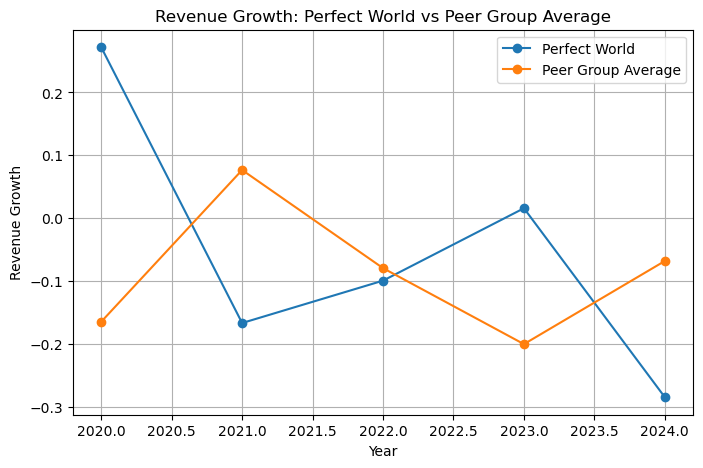

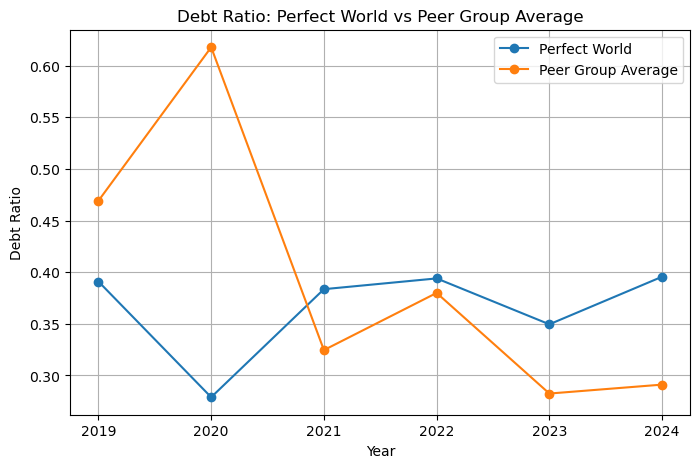

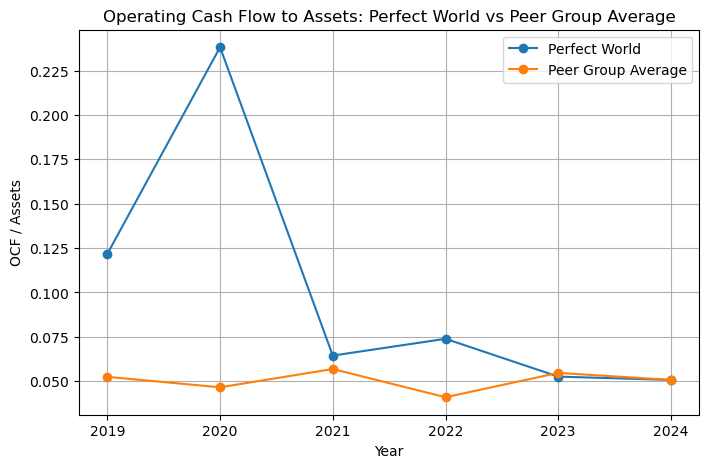

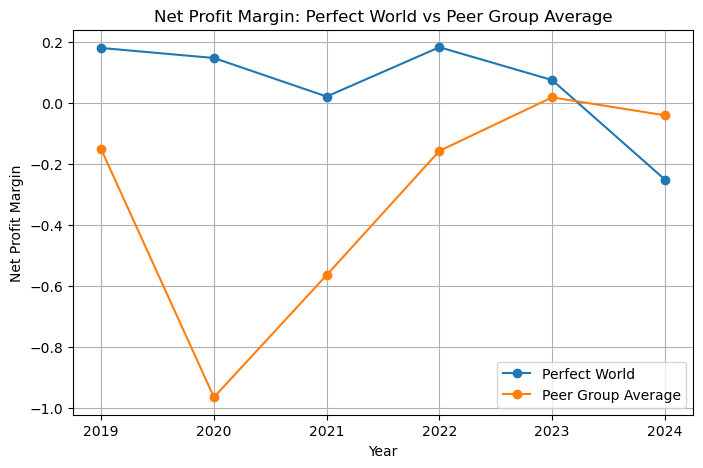

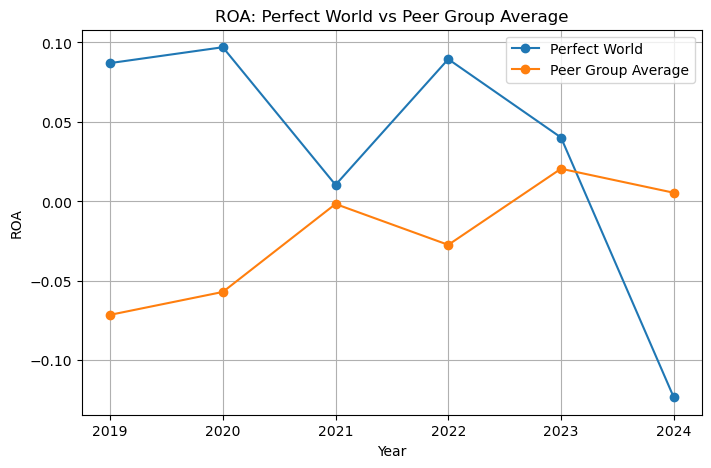

In [10]:
import matplotlib.pyplot as plt

# Plot revenue growth comparison
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['revenue_growth_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['revenue_growth_industry'], marker='o', label='Peer Group Average')
plt.title('Revenue Growth: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Revenue Growth')
plt.legend()
plt.grid(True)
plt.show()

# Plot debt ratio comparison
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['debt_ratio_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['debt_ratio_industry'], marker='o', label='Peer Group Average')
plt.title('Debt Ratio: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Debt Ratio')
plt.legend()
plt.grid(True)
plt.show()

# Plot operating cash flow to assets comparison
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['ocf_to_assets_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['ocf_to_assets_industry'], marker='o', label='Peer Group Average')
plt.title('Operating Cash Flow to Assets: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('OCF / Assets')
plt.legend()
plt.grid(True)
plt.show()

# Plot net profit margin comparison
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['net_profit_margin_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['net_profit_margin_industry'], marker='o', label='Peer Group Average')
plt.title('Net Profit Margin: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('Net Profit Margin')
plt.legend()
plt.grid(True)
plt.show()

# Plot ROA comparison
plt.figure(figsize=(8, 5))
plt.plot(comparison['year'], comparison['roa_company'], marker='o', label='Perfect World')
plt.plot(comparison['year'], comparison['roa_industry'], marker='o', label='Peer Group Average')
plt.title('ROA: Perfect World vs Peer Group Average')
plt.xlabel('Year')
plt.ylabel('ROA')
plt.legend()
plt.grid(True)
plt.show()

## 9. Summarise the Average Differences

This section calculates the average level of each indicator for Perfect World and for the refined peer group. The averages are then used to produce a simple overall interpretation.

In [11]:
# Calculate the average value of each indicator for Perfect World and the peer group
avg_company_growth = comparison['revenue_growth_company'].mean()
avg_ind_growth = comparison['revenue_growth_industry'].mean()

avg_company_debt = comparison['debt_ratio_company'].mean()
avg_ind_debt = comparison['debt_ratio_industry'].mean()

avg_company_ocf = comparison['ocf_to_assets_company'].mean()
avg_ind_ocf = comparison['ocf_to_assets_industry'].mean()

avg_company_margin = comparison['net_profit_margin_company'].mean()
avg_ind_margin = comparison['net_profit_margin_industry'].mean()

avg_company_roa = comparison['roa_company'].mean()
avg_ind_roa = comparison['roa_industry'].mean()

print("Average revenue growth - Perfect World:", round(avg_company_growth, 4))
print("Average revenue growth - Peer group:", round(avg_ind_growth, 4))
print("Average debt ratio - Perfect World:", round(avg_company_debt, 4))
print("Average debt ratio - Peer group:", round(avg_ind_debt, 4))
print("Average OCF/Assets - Perfect World:", round(avg_company_ocf, 4))
print("Average OCF/Assets - Peer group:", round(avg_ind_ocf, 4))
print("Average net profit margin - Perfect World:", round(avg_company_margin, 4))
print("Average net profit margin - Peer group:", round(avg_ind_margin, 4))
print("Average ROA - Perfect World:", round(avg_company_roa, 4))
print("Average ROA - Peer group:", round(avg_ind_roa, 4))

Average revenue growth - Perfect World: -0.0528
Average revenue growth - Peer group: -0.0874
Average debt ratio - Perfect World: 0.3654
Average debt ratio - Peer group: 0.3942
Average OCF/Assets - Perfect World: 0.1002
Average OCF/Assets - Peer group: 0.0504
Average net profit margin - Perfect World: 0.059
Average net profit margin - Peer group: -0.3105
Average ROA - Perfect World: 0.0335
Average ROA - Peer group: -0.0219


## 10. Rule-Based Summary Interpretation

A simple rule-based scoring method is used to translate multiple financial indicators into an easy-to-understand summary. This is intended as a communication device rather than a formal predictive model.

The score does not guarantee future game success or continuous updates. Instead, it provides a simplified financial signal based on relative growth, financial pressure, profitability, and operating cash support.

In [12]:
# Use a simple rule-based scoring method to summarise the comparison
score = 0

# Higher revenue growth is considered stronger
if avg_company_growth > avg_ind_growth:
    score += 1

# Lower debt ratio is considered safer
if avg_company_debt < avg_ind_debt:
    score += 1

# Higher operating cash flow to assets is considered stronger
if avg_company_ocf > avg_ind_ocf:
    score += 1

# Higher net profit margin is considered stronger
if avg_company_margin > avg_ind_margin:
    score += 1

# Higher ROA is considered stronger
if avg_company_roa > avg_ind_roa:
    score += 1

# Generate the final conclusion
if score >= 4:
    conclusion = "Perfect World appears financially stronger than the refined peer group average and may present relatively lower long-term spending risk for paying players."
elif score == 3:
    conclusion = "Perfect World shows moderately strong financial performance relative to the refined peer group, suggesting moderate to relatively lower long-term spending risk."
elif score == 2:
    conclusion = "Perfect World shows mixed financial performance relative to the refined peer group, suggesting moderate long-term spending risk."
else:
    conclusion = "Perfect World appears financially weaker than the refined peer group average, which may indicate relatively higher long-term spending risk for paying players."

print(conclusion)

Perfect World appears financially stronger than the refined peer group average and may present relatively lower long-term spending risk for paying players.


In [13]:
db.close()